In [1]:
import csv
import os
from typing import Literal
from dataclasses import dataclass
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
@dataclass
class SubjectResult:
    filename: str
    gender: str
    trial: int
    choice: int
    outcome: str
    choice_rt: float
    confidence_level: int
    confidence_rt: float
    next_trial_rt: float
    card_probs: list[float]


In [3]:

DATADIR_PATH = "./Data"

def read_subject_data(gender: Literal['Male', 'Female'], filename: str) -> list[SubjectResult]:
    filepath = os.path.join(DATADIR_PATH, gender, filename)
    results: list[SubjectResult] = []
    with open(filepath, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            results.append(SubjectResult(
                filename=filename,
                gender=gender,
                trial=int(row['trial']),
                choice=int(row['choice']),
                outcome=row['outcome'],
                choice_rt=float(row['choice_rt']),
                confidence_level=int(row['confidence_level']),
                confidence_rt=float(row['confidence_rt']),
                next_trial_rt=float(row['next_trial_rt']),
                card_probs=eval(row['card probs']),
            ))
    return results

def read_all_data() -> list[SubjectResult]:
    all_results: list[SubjectResult] = []
    for gender in ('Male', 'Female'):
        gender_dir = os.path.join(DATADIR_PATH, gender)
        for filename in os.listdir(gender_dir):
            all_results.extend(read_subject_data(gender,filename))
    return all_results

subjects_data = read_all_data()
df = pd.DataFrame([vars(r) for r in subjects_data])

def assign_block(trial):
    if trial < 15:
        return 1
    elif trial < 45:
        return 2
    return 3

df['block'] = df['trial'].apply(assign_block)
df['trial_in_block'] = df.groupby(['filename', 'block']).cumcount() + 1

df['chosen_probability'] = df.apply(
    lambda row: row['card_probs'][row['choice']],
    axis=1
)

df['optimal_choice'] = (
    df['chosen_probability']
    == 0.7
).astype(int)

df['rewarded'] = (df['outcome'] == 'win').astype(int)

df


,filename,gender,trial,choice,outcome,choice_rt,confidence_level,confidence_rt,next_trial_rt,card_probs,block,trial_in_block,chosen_probability,optimal_choice,rewarded
0,subject3.csv,Male,0,1,win,2.865571,3,3.362912,1.389576,"[0.6, 0.7, 0.4, 0.5]",1,1,0.7,1,1
1,subject3.csv,Male,1,3,lose,3.235349,2,2.570418,0.749804,"[0.6, 0.7, 0.4, 0.5]",1,2,0.5,0,0
2,subject3.csv,Male,2,0,win,4.040312,2,1.957961,0.466987,"[0.6, 0.7, 0.4, 0.5]",1,3,0.6,0,1
3,subject3.csv,Male,3,1,win,3.209114,2,1.417447,0.726657,"[0.6, 0.7, 0.4, 0.5]",1,4,0.7,1,1
4,subject3.csv,Male,4,0,lose,4.824815,2,1.825226,0.987631,"[0.6, 0.7, 0.4, 0.5]",1,5,0.6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,subject40.csv,Female,100,1,win,0.430288,4,0.367059,0.287287,"[0.7, 0.5, 0.6, 0.4]",3,56,0.5,0,1
4196,subject40.csv,Female,101,1,win,0.848554,4,0.467245,1.242851,"[0.7, 0.5, 0.6, 0.4]",3,57,0.5,0,1
4197,subject40.csv,Female,102,1,lose,0.293267,5,0.251661,1.231314,"[0.7, 0.5, 0.6, 0.4]",3,58,0.5,0,0
4198,subject40.csv,Female,103,1,win,0.270532,5,0.475281,1.998850,"[0.7, 0.5, 0.6, 0.4]",3,59,0.5,0,1


In [4]:
d = df[df['filename'] == 'subject40.csv']
p = {}
for i in d['card_probs']:
    k = tuple(i)
    if k not in p:
        p[k] = 0
    p[k]+=1
p

{(0.6, 0.5, 0.4, 0.7): 15, (0.6, 0.5, 0.7, 0.4): 30, (0.7, 0.5, 0.6, 0.4): 60}

In [5]:
print("nan count", np.count_nonzero(df.isna()))

nan count 0


In [6]:
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#8C8C8C']
RT_COLS = ('choice_rt', 'confidence_rt', 'next_trial_rt')
NUMBER_DTYPES = (int, float)
INCLUDED_NON_NUMBER_COLS = ('gender', 'outcome')
EXCLUDED_COLS = ('trial',)
HIST_COLS = list(filter(
    lambda c: ((df[c].dtype in NUMBER_DTYPES) or (c in INCLUDED_NON_NUMBER_COLS))
    and c not in EXCLUDED_COLS,
    df.columns
))
FIGSIZE_WIDE = (10, 5)
FIGSIZE_LARGE = (12, 8)
FIGSIZE_TRIPLE = (15, 4)

def add_block_vlines(ax, xs=[15, 45]):
    for xv in xs:
        ax.axvline(x=xv, color='grey', linestyle='--', alpha=0.7)

ROLLING_WINDOW = 5
def rolling_entropy(choices, window=10):
    entropies = []
    for i in range(len(choices)):
        start = max(0, i - window + 1)
        window_choices = choices[start:i+1]
        counts = pd.Series(window_choices).value_counts()
        probs = counts.values / counts.sum()
        entropies.append(-sum(p * np.log2(p) for p in probs if p > 0))
    return entropies

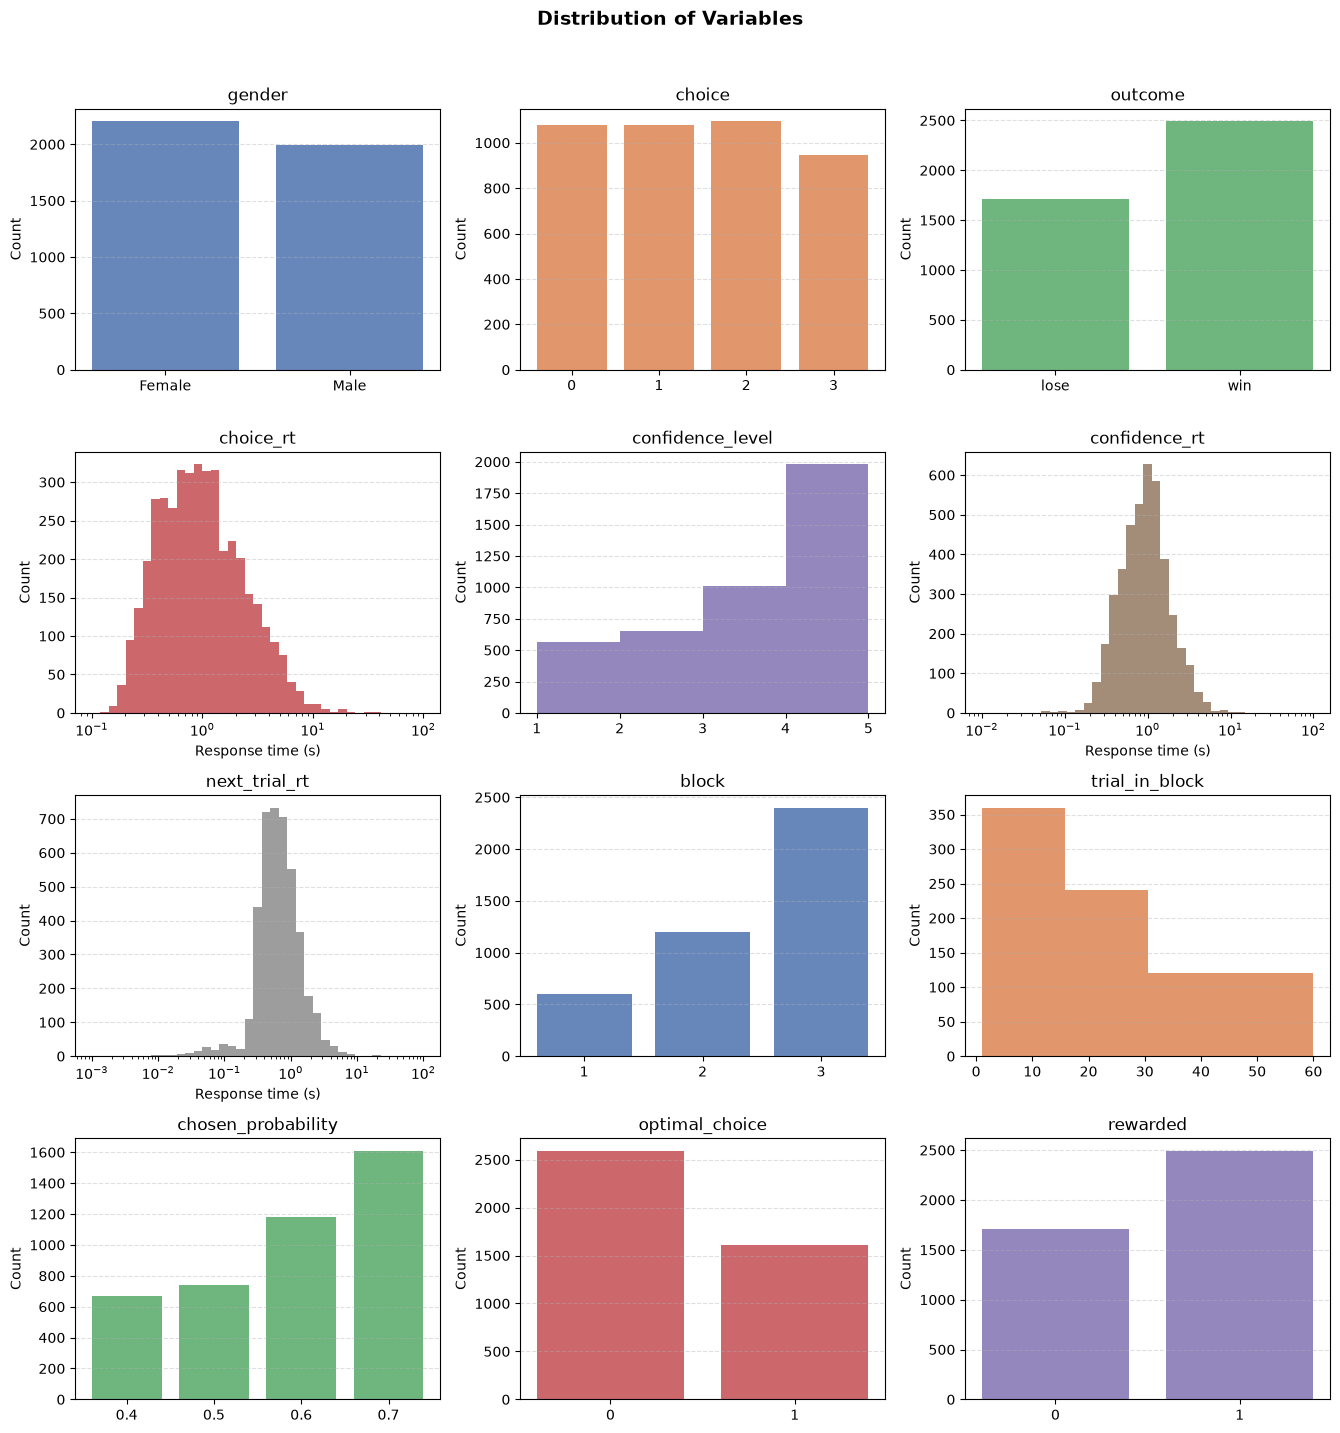

In [7]:
# Histogram of numeric cols
# log for response time data
# bar for low cardinality
# hist for high cardinality

n1 = len(HIST_COLS)
cols = 3
rows = int(np.ceil(n1 / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5))
axes = np.ravel(axes)

for i, col in enumerate(HIST_COLS):
    ax = axes[i]
    data = df[col]
    color = PALETTE[i % len(PALETTE)]
    if col in RT_COLS :
        log_min = np.floor(np.log10(data.min()))
        log_max = np.ceil(np.log10(data.max()))
        bins = np.logspace(log_min, log_max, 40)
        ax.hist(data, bins=bins, color=color, alpha=0.85)
        ax.set_xscale('log')
        ax.set_xlabel('Response time (s)')
    elif data.nunique() >= 5:
        ax.hist(data, bins='auto', color=color, alpha=0.85)
    else:
        counts = data.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.85)
    ax.set_ylabel('Count')
    ax.set_title(col)
    ax.grid(axis='y', linestyle='--', alpha=0.4)


plt.suptitle('Distribution of Variables', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("report/pics/histogram_distribution.png", dpi=150)
plt.show()


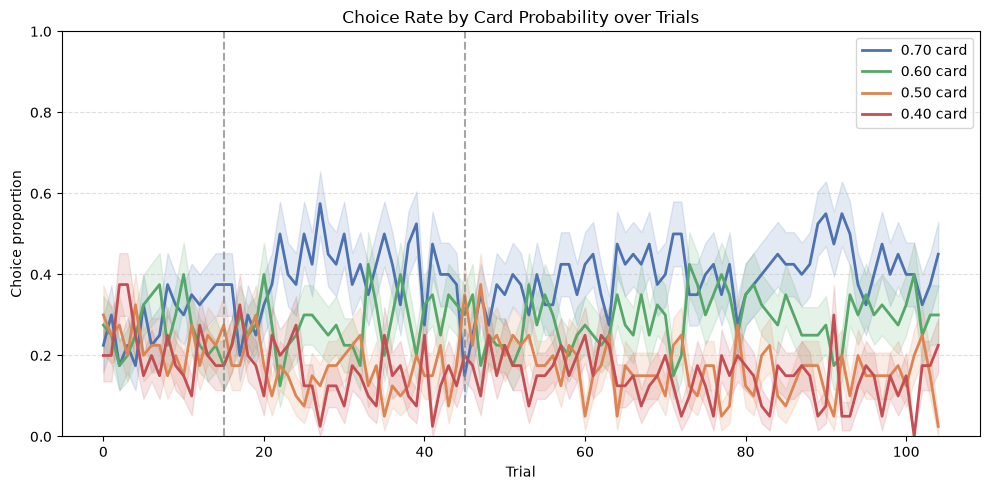

In [8]:

probs = [0.70, 0.60, 0.50, 0.40]
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

for prob, color in zip(probs, colors):
    grouped = df.groupby('trial')['chosen_probability']

    choice_rate = grouped.apply(lambda x: (x == prob).mean())
    sem = grouped.apply(lambda x: (x == prob).sem())

    ax.plot(choice_rate.index, choice_rate.values,
            color=color, linewidth=2, label=f'{prob:.2f} card')

    ax.fill_between(
        choice_rate.index,
        choice_rate - sem,
        choice_rate + sem,
        color=color,
        alpha=0.15
    )

ax.set_xlabel('Trial')
ax.set_ylabel('Choice proportion')
ax.set_title('Choice Rate by Card Probability over Trials')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for xv in [15, 45]:
    ax.axvline(x=xv, color='grey', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("report/pics/choice_rate_by_probability.png", dpi=150)
plt.show()

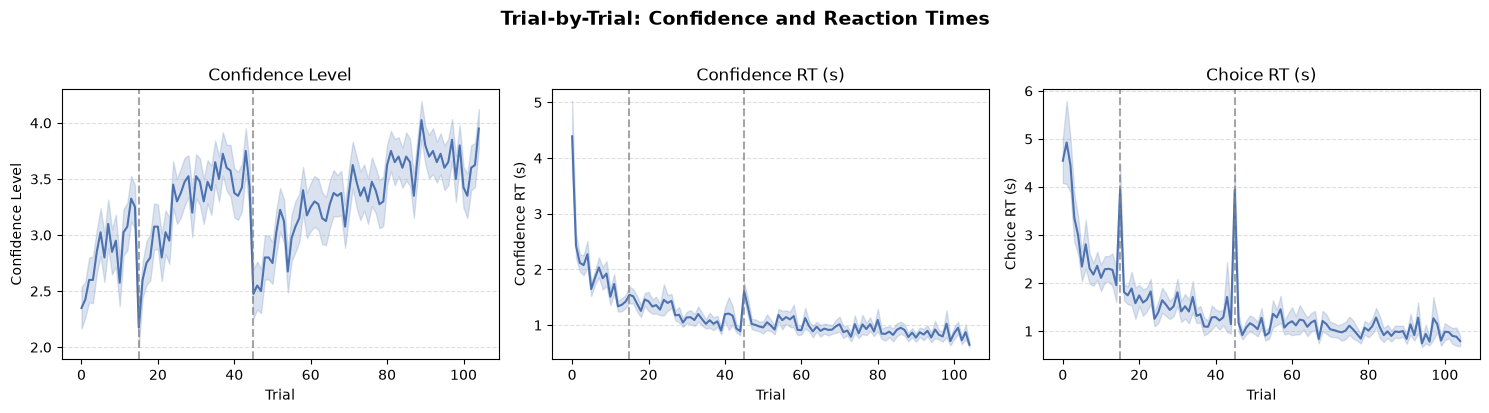

In [9]:

trial_cols = ['confidence_level', 'confidence_rt', 'choice_rt']
trial_labels = ['Confidence Level', 'Confidence RT (s)', 'Choice RT (s)']

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_TRIPLE)
axes = np.ravel(axes)

for ax, col, label in zip(axes, trial_cols, trial_labels):
    mean_by_trial = df.groupby('trial')[col].mean()
    sem_by_trial = df.groupby('trial')[col].sem()
    ax.plot(mean_by_trial.index, mean_by_trial.values, color='#4C72B0')
    ax.fill_between(mean_by_trial.index, mean_by_trial.values - sem_by_trial.values, mean_by_trial.values + sem_by_trial.values, color='#4C72B0', alpha=0.2)
    ax.set_xlabel('Trial')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for xv in [15, 45]:
        ax.axvline(x=xv, color='grey', linestyle='--', alpha=0.7)

plt.suptitle('Trial-by-Trial: Confidence and Reaction Times', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("report/pics/trial_by_trial_confidence_rt.png", dpi=150)
plt.show()

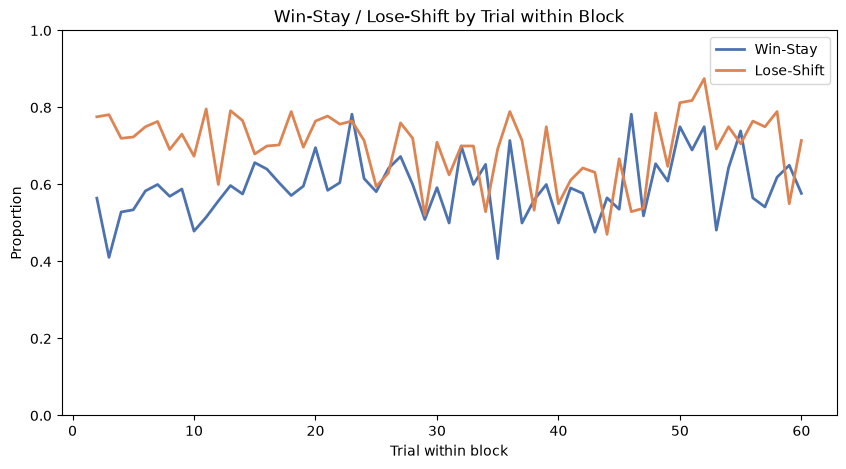

In [10]:

wsls = df.copy().sort_values(['filename', 'block', 'trial'])
group_cols = ['filename', 'block']
wsls['prev_outcome'] = wsls.groupby(group_cols)['outcome'].shift(1)
wsls['prev_choice'] = wsls.groupby(group_cols)['choice'].shift(1)
wsls = wsls.dropna(subset=['prev_outcome', 'prev_choice'])

wsls['win_stay'] = (wsls['prev_outcome'] == 'win') & (wsls['choice'] == wsls['prev_choice'])
wsls['lose_shift'] = (wsls['prev_outcome'] == 'lose') & (wsls['choice'] != wsls['prev_choice'])

win_stay_by_trial = wsls[wsls['prev_outcome'] == 'win'].groupby('trial_in_block')['win_stay'].mean()
lose_shift_by_trial = wsls[wsls['prev_outcome'] == 'lose'].groupby('trial_in_block')['lose_shift'].mean()

plt.figure(figsize=FIGSIZE_WIDE)
plt.plot(win_stay_by_trial.index, win_stay_by_trial.values, label='Win-Stay', color='#4C72B0', linewidth=2)
plt.plot(lose_shift_by_trial.index, lose_shift_by_trial.values, label='Lose-Shift', color='#DD8452', linewidth=2)
plt.xlabel('Trial within block')
plt.ylabel('Proportion')
plt.legend()
plt.ylim(0, 1)
plt.title('Win-Stay / Lose-Shift by Trial within Block')
plt.savefig("report/pics/win_stay_lose_shift.png", dpi=150)
plt.show()

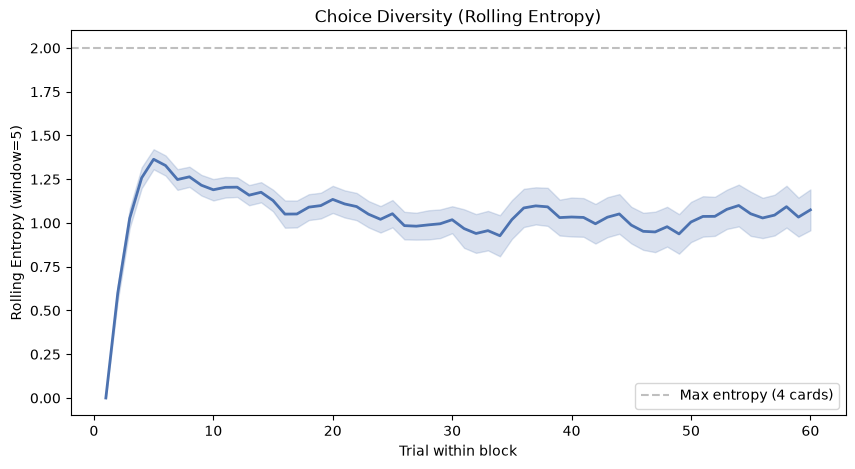

In [11]:

results = []

for (subj, block), group in df.sort_values('trial').groupby(['filename', 'block']):
    choices = group['choice'].values
    trials = group['trial_in_block'].values
    entropies = rolling_entropy(choices, window=ROLLING_WINDOW)
    for t, e in zip(trials, entropies):
        results.append({'trial_in_block': t, 'block': block, 'entropy': e})

res_df = pd.DataFrame(results)
mean_entropy = res_df.groupby('trial_in_block')['entropy'].mean()
sem_entropy = res_df.groupby('trial_in_block')['entropy'].sem()

plt.figure(figsize=FIGSIZE_WIDE)
plt.plot(mean_entropy.index, mean_entropy.values, color='#4C72B0', linewidth=2)
plt.fill_between(mean_entropy.index, mean_entropy.values - sem_entropy.values, mean_entropy.values + sem_entropy.values, color='#4C72B0', alpha=0.2)
plt.axhline(y=np.log2(4), color='grey', linestyle='--', alpha=0.5, label='Max entropy (4 cards)')
plt.xlabel('Trial within block')
plt.ylabel('Rolling Entropy (window=' + str(ROLLING_WINDOW) + ')')
plt.legend()
plt.title('Choice Diversity (Rolling Entropy)')
plt.savefig("report/pics/rolling_entropy.png", dpi=150)
plt.show()

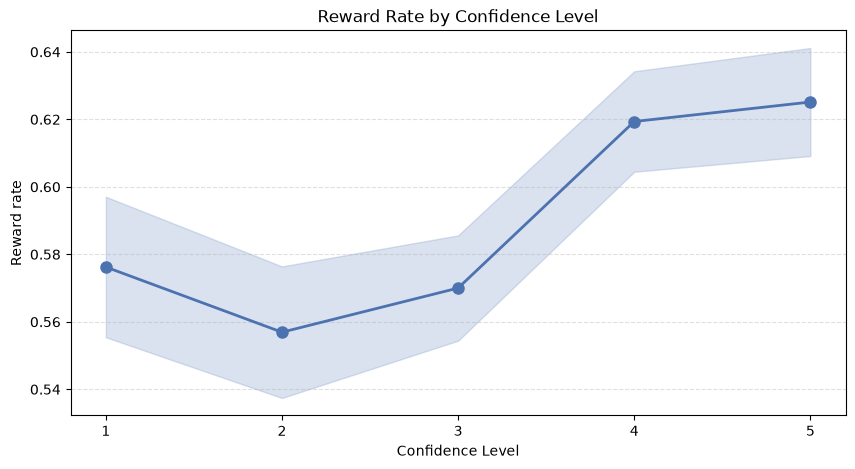

In [12]:

cal = df.copy()
cal['rewarded'] = (cal['outcome'] == 'win').astype(int)
acc = cal.groupby('confidence_level')['rewarded'].agg(['mean', 'sem', 'count'])
acc = acc.reset_index()

plt.figure(figsize=FIGSIZE_WIDE)
plt.plot(acc['confidence_level'], acc['mean'], marker='o', color='#4C72B0', linewidth=2, markersize=8)
plt.fill_between(acc['confidence_level'], acc['mean'] - acc['sem'], acc['mean'] + acc['sem'], color='#4C72B0', alpha=0.2)
plt.xlabel('Confidence Level')
plt.ylabel('Reward rate')
plt.xticks([1, 2, 3, 4, 5])
plt.title('Reward Rate by Confidence Level')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig("report/pics/reward_rate_by_confidence.png", dpi=150)
plt.show()

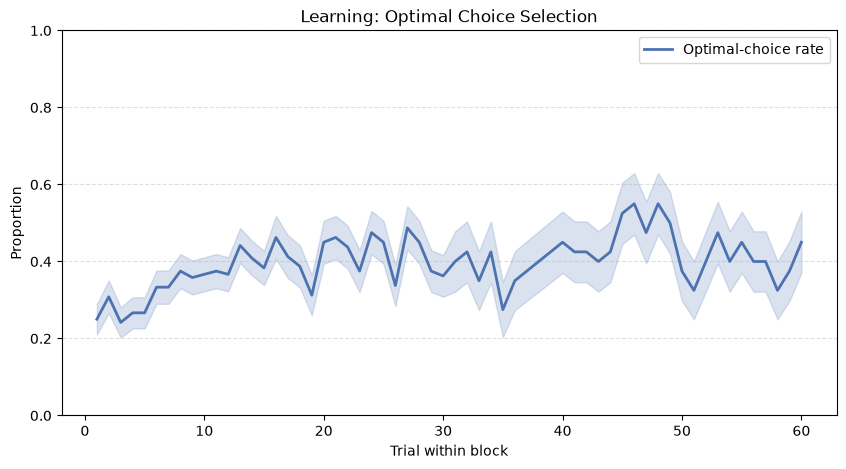

In [13]:

optimal_by_trial = df.groupby('trial_in_block')['optimal_choice'].mean()
sem_optimal = df.groupby('trial_in_block')['optimal_choice'].sem()

plt.figure(figsize=FIGSIZE_WIDE)
plt.plot(optimal_by_trial.index, optimal_by_trial.values, label='Optimal-choice rate', color='#4C72B0', linewidth=2)
plt.fill_between(optimal_by_trial.index, optimal_by_trial.values - sem_optimal.values, optimal_by_trial.values + sem_optimal.values, color='#4C72B0', alpha=0.2)
plt.xlabel('Trial within block')
plt.ylabel('Proportion')
plt.legend()
plt.ylim(0, 1)
plt.title('Learning: Optimal Choice Selection')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig("report/pics/learning_optimal_choice.png", dpi=150)
plt.show()

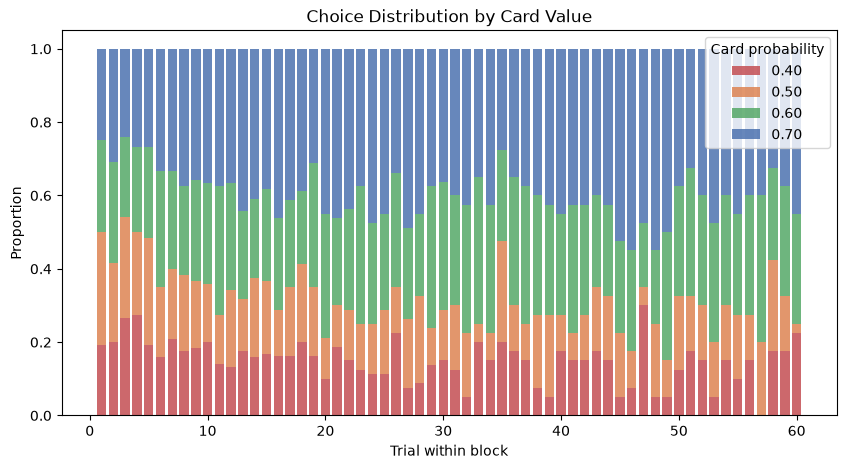

In [14]:

df['card_value'] = df['chosen_probability'].apply(lambda p: f'{p:.2f}')
value_order = ['0.40', '0.50', '0.60', '0.70']
card_counts = df.groupby(['trial_in_block', 'card_value']).size().unstack(fill_value=0)
card_props = card_counts.div(card_counts.sum(axis=1), axis=0)
card_props = card_props.reindex(columns=value_order, fill_value=0)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bottom = np.zeros(len(card_props))
colors = {'0.40': '#C44E52', '0.50': '#DD8452', '0.60': '#55A868', '0.70': '#4C72B0'}
for val in value_order:
    ax.bar(card_props.index, card_props[val], bottom=bottom, label=val, color=colors[val], alpha=0.85, width=0.8)
    bottom += card_props[val].values

ax.set_xlabel('Trial within block')
ax.set_ylabel('Proportion')
ax.set_title('Choice Distribution by Card Value')
ax.legend(title='Card probability')
plt.savefig("report/pics/choice_distribution_by_card_value.png", dpi=150)
plt.show()

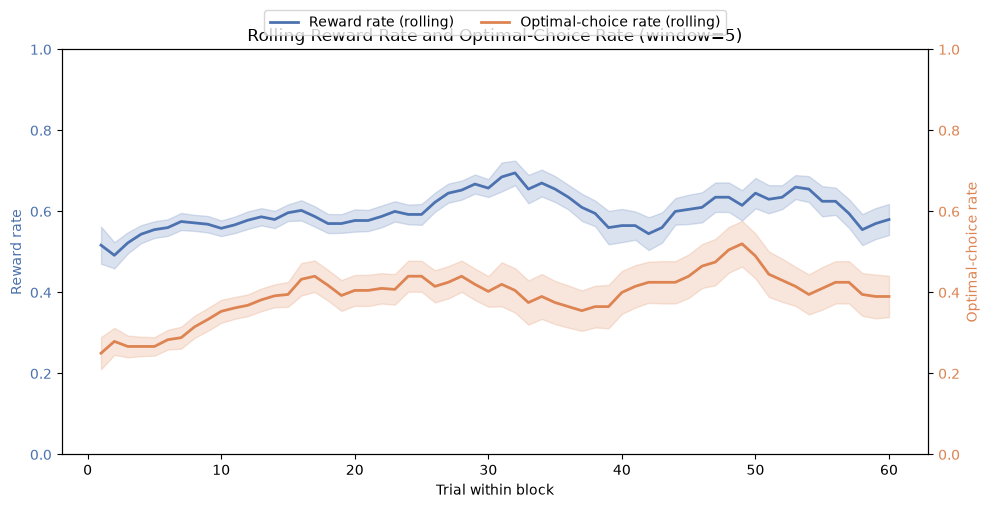

In [15]:

# use ROLLING_WINDOW from top-level constants
df_sorted = df.sort_values(['filename', 'block', 'trial'])
rolling = df_sorted.groupby(['filename', 'block']).apply(
    lambda g: g.rolling(ROLLING_WINDOW, on='trial_in_block', min_periods=1)[['rewarded', 'optimal_choice']].mean()
).reset_index()
rolling_by_trial = rolling.groupby('trial_in_block')[['rewarded', 'optimal_choice']].mean()
sem_by_trial = rolling.groupby('trial_in_block')[['rewarded', 'optimal_choice']].sem()

fig, ax1 = plt.subplots(figsize=FIGSIZE_WIDE)
ax1.plot(rolling_by_trial.index, rolling_by_trial['rewarded'], color='#4C72B0', linewidth=2, label='Reward rate (rolling)')
ax1.fill_between(rolling_by_trial.index, rolling_by_trial['rewarded'] - sem_by_trial['rewarded'], rolling_by_trial['rewarded'] + sem_by_trial['rewarded'], color='#4C72B0', alpha=0.2)
ax1.set_xlabel('Trial within block')
ax1.set_ylabel('Reward rate', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(rolling_by_trial.index, rolling_by_trial['optimal_choice'], color='#DD8452', linewidth=2, label='Optimal-choice rate (rolling)')
ax2.fill_between(rolling_by_trial.index, rolling_by_trial['optimal_choice'] - sem_by_trial['optimal_choice'], rolling_by_trial['optimal_choice'] + sem_by_trial['optimal_choice'], color='#DD8452', alpha=0.2)
ax2.set_ylabel('Optimal-choice rate', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, 1)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2)
plt.title('Rolling Reward Rate and Optimal-Choice Rate (window=' + str(ROLLING_WINDOW) + ')')
plt.tight_layout()
plt.savefig("report/pics/rolling_reward_optimal_choice.png", dpi=150)
plt.show()

In [16]:

def calc_pvalue(p0, phat, N):
    z = (phat - p0) / np.sqrt(p0 * (1 - p0) / N)
    p_value = stats.norm.sf(z)   # one-sided upper-tail
    return p_value

def get_hypothesis(n: int):
    dist = df[df["block"] == 3][["trial_in_block", "rewarded"]]
    dist1 = dist[dist["trial_in_block"] <= n]
    dist2 = dist[dist["trial_in_block"] > 60 - n]
    assert len(dist1) == len(dist2)
    h0 = dist1["rewarded"].mean()
    h1 = dist2["rewarded"].mean()
    return h0, h1, len(dist1)
n = 15
alpha = 0.05

h0, h1, N = get_hypothesis(n)
print("First trials rewarded mean:", h0)
print("Last trials rewarded mean:", h1)

pvalue1 = calc_pvalue(0.55, h0, N)
pvalue2 = calc_pvalue(0.55, h1, N)
print(f"p-value for first {n} trials: {pvalue1:.4f}")
print(f"p-value for last {n} trials: {pvalue2:.4f}")

result1 = "Reject" if pvalue1 < alpha else "Fail to reject"
result2 = "Reject" if pvalue2 < alpha else "Fail to reject"
print(f"Result for first {n} trials: {result1} H0")
print(f"Result for last {n} trials: {result2} H0")


print("#################################################")

h0, h1, N = get_hypothesis(n)
p_value_first_last = calc_pvalue(h0, h1, N)
print(f"p-value for first {n} vs last {n} trials: {p_value_first_last:.4f}")
result_first_last = "Reject" if p_value_first_last < alpha else "Fail to reject"
print(f"Result for first {n} vs last {n} trials: {result_first_last} H0")
# if p_value < alpha:
#     print("Reject H0: evidence that performance is above chance.")
# else:
#     print("Fail to reject H0.")

First trials rewarded mean: 0.5733333333333334
Last trials rewarded mean: 0.6166666666666667
p-value for first 15 trials: 0.1253
p-value for last 15 trials: 0.0005
Result for first 15 trials: Fail to reject H0
Result for last 15 trials: Reject H0
#################################################
p-value for first 15 vs last 15 trials: 0.0159
Result for first 15 vs last 15 trials: Reject H0
